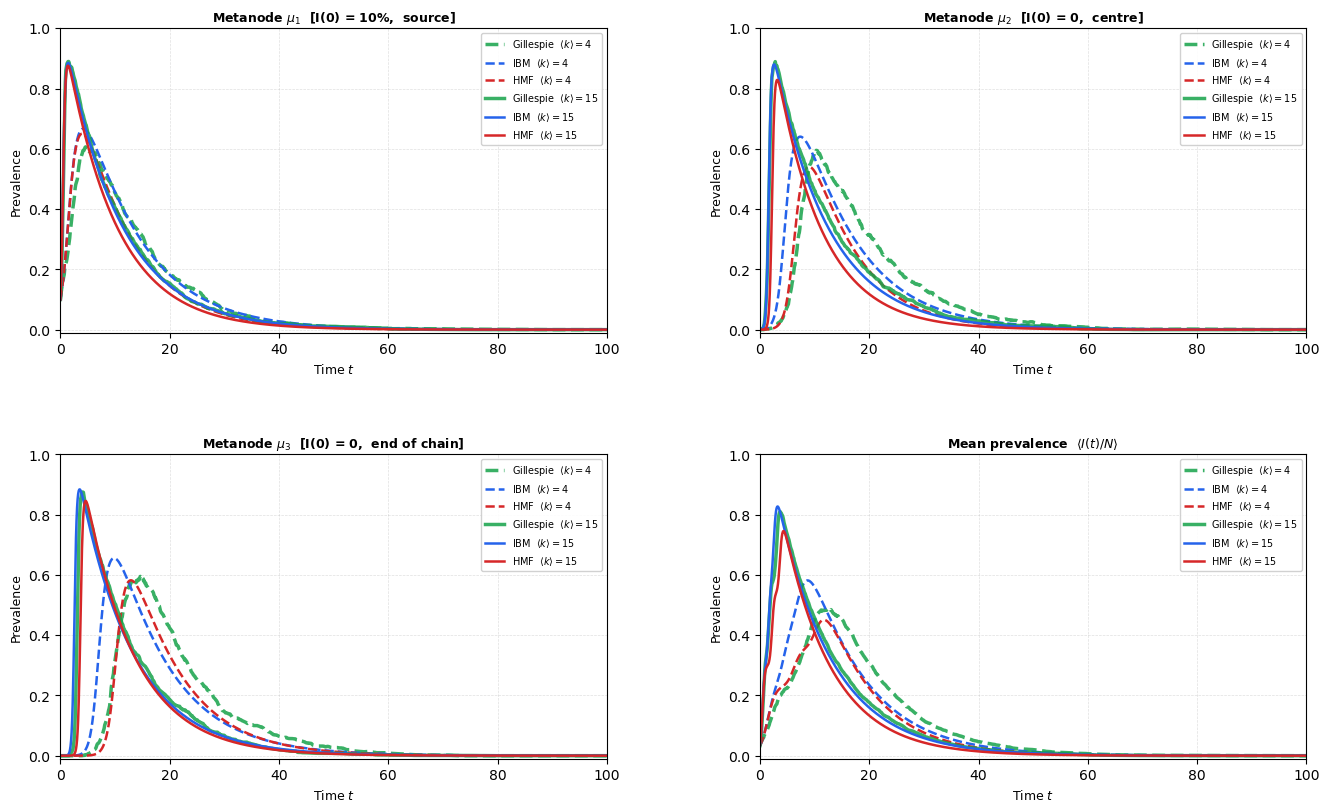

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
import networkx as nx
np.random.seed(3)

#Parameters
beta   = 0.3 #transmission rate
gamma  = 0.1 # recovery rate
D_I    = 0.01 #diffusion rate
M      = 3 # number of metanodes
N      = 1000 # number of node in each metande
T_max  = 100
k_list = [4, 15] # average degree

A_meta   = D_I * np.array([[0,1,0],[1,0,1],[0,1,0]], dtype=float) # DI. A (A adacencymatrix of metanetwork)
D_meta   = np.diag(A_meta.sum(axis=1)) # matrix of degree
L_meta   = D_meta - A_meta #Laplacian of the metanetwrk
D_mu_vec = np.diag(L_meta) #
D_mu0    = D_mu_vec[0] # DI.k_mu1
pi_mu0   = 1.0 / M # the stationary distribution

 
# Gillespie
def gillespie_SIR(beta, gamma, A_meta, M, N, adjs, T_max, seed=3):
    #np.random.seed(seed)
    state = [np.zeros(N, dtype=int) for _ in range(M)] 
    state[0][:max(1, int(0.10 * N))] = 1
    times = [0.0]
    I_counts = [[np.sum(s == 1) for s in state]]
    t = 0.0
    for _ in range(800_000):
        rates = []; events = []
        for mu in range(M):
            adj = adjs[mu]; s = state[mu]
            for i in range(N):
                if s[i] == 0:
                    inf_nb = sum(1 for j in adj[i] if s[j] == 1)
                    if inf_nb > 0:
                        rates.append(beta * inf_nb)
                        events.append(('infect', mu, i, None))
                elif s[i] == 1:
                    rates.append(gamma)
                    events.append(('recover', mu, i, None))
                    for nu in range(M):
                        if A_meta[mu, nu] > 0:
                            rates.append(A_meta[mu, nu])
                            events.append(('migrate', mu, i, nu))
        total_rate = sum(rates)
        if total_rate == 0:
            break
        t += np.random.exponential(1.0 / total_rate)
        if t > T_max: 
            break
        r = np.random.random() * total_rate
        cumsum = 0
        for idx, rate in enumerate(rates):
            cumsum += rate
            if r <= cumsum:
                etype, mu, i, nu = events[idx]
                break
        if etype == 'infect': state[mu][i] = 1
        elif etype == 'recover': state[mu][i] = 2
        elif etype == 'migrate':
            dest_S = np.where(state[nu] == 0)[0]
            if len(dest_S) > 0:
                state[mu][i] = 0
                state[nu][dest_S[np.random.randint(len(dest_S))]] = 1
        times.append(t)
        I_counts.append([np.sum(s == 1) for s in state])
    return np.array(times), np.array(I_counts, dtype=float) / N  # time and the prevalence

#IBM ODE
def ode_IBM_SIR(t, X, beta, gamma, N, M, As, L_meta):
    X = np.clip(X, 0.0, 1.0)
    dX = np.zeros(3 * N * M)
    for mu in range(M):
        S_mu = X[mu*3*N : mu*3*N + N]
        I_mu = X[mu*3*N + N : mu*3*N + 2*N]
        infection = beta * S_mu * (As[mu] @ I_mu)
        recovery = gamma * I_mu
        mig_S = sum(L_meta[mu,nu]*X[nu*3*N : nu*3*N + N] for nu in range(M))
        mig_I = sum(L_meta[mu,nu]*X[nu*3*N + N : nu*3*N + 2*N] for nu in range(M))
        dX[mu*3*N : mu*3*N + N] = - infection - mig_S
        dX[mu*3*N + N : mu*3*N + 2*N] = +infection - recovery - mig_I
        dX[mu*3*N + 2*N: mu*3*N + 3*N] = +recovery
    return dX

# HMF ODE
def build_patch_info(p_ks, degrees_all, M):
    patch_info = []; offset = 0
    for mu in range(M):
        k_classes = np.array(sorted(p_ks[mu].keys()), dtype=float)
        p_k_arr = np.array([p_ks[mu][int(k)] for k in k_classes])
        n_k = len(k_classes)
        patch_info.append({'k_classes': k_classes, 'p_k_arr': p_k_arr,
                           'k_mean': float(np.mean(degrees_all[mu])),
                           'n_k': n_k, 'offset': offset})
        offset += n_k
    return patch_info, offset

def ode_HMF_SIR(t, X, beta, gamma, M, D_mu_vec, A_meta, patch_info, total_k):
    X = np.clip(X, 0.0, 1.0)
    dX = np.zeros_like(X)
    Theta = np.zeros(M); sumI = np.zeros(M); sumS = np.zeros(M)
    for mu in range(M):
        info = patch_info[mu]; off = info['offset']; n_k = info['n_k']
        I_kmu = X[total_k + off : total_k + off + n_k]
        S_kmu = X[off : off + n_k]
        Theta[mu] = np.dot(info['k_classes']*info['p_k_arr'], I_kmu) / info['k_mean']
        sumI[mu] = np.dot(info['p_k_arr'], I_kmu)
        sumS[mu] = np.dot(info['p_k_arr'], S_kmu)
    for mu in range(M):
        info = patch_info[mu]; off = info['offset']; n_k = info['n_k']
        S_kmu = X[off : off + n_k]
        I_kmu = X[total_k + off : total_k + off + n_k]
        k_cls = info['k_classes']; p_k_arr = info['p_k_arr']
        infection = beta * k_cls * S_kmu * Theta[mu]
        recovery = gamma * I_kmu
        outflow_S = D_mu_vec[mu] * S_kmu
        outflow_I = D_mu_vec[mu] * I_kmu
        inflow_S = p_k_arr * sum(A_meta[nu,mu]*sumS[nu] for nu in range(M) if A_meta[nu,mu]>0)
        inflow_I = p_k_arr * sum(A_meta[nu,mu]*sumI[nu] for nu in range(M) if A_meta[nu,mu]>0)
        dX[off : off + n_k] = -infection - outflow_S + inflow_S
        dX[total_k + off : total_k + off + n_k] = infection - recovery  - outflow_I + inflow_I
        dX[2*total_k+off : 2*total_k+off + n_k] = recovery
    return dX

# Main loop
t_eval = np.linspace(0, T_max, 2000)
t_fine = np.linspace(0, T_max, 1000)
results = []

#building of the network
for k_avg in k_list:
    adjs, As, degrees_all, p_ks = [], [], [], []
    for mu in range(M):
        G = nx.erdos_renyi_graph(N, k_avg/(N-1), seed=mu)
        A = nx.to_numpy_array(G)
        adj = [list(G.neighbors(i)) for i in range(N)]
        deg = np.array([d for _, d in G.degree()])
        uk, cnt = np.unique(deg, return_counts=True)
        pk = {int(k): c / (N-1) for k, c in zip(uk, cnt)}
        adjs.append(adj); As.append(A)
        degrees_all.append(deg); p_ks.append(pk)

    patch_info, total_HMF = build_patch_info(p_ks, degrees_all, M)

    X0_IBM = np.zeros(3 * N * M)
    for mu in range(M):
        X0_IBM[mu*3*N : mu*3*N + N] = 1.0
    X0_IBM[0:N] = 0.90; X0_IBM[N:2*N] = 0.10

    X0_HMF = np.zeros(3 * total_HMF)
    info0 = patch_info[0]; off0 = info0['offset']; n_k0 = info0['n_k']
    X0_HMF[off0 : off0 + n_k0]                         = 0.90
    X0_HMF[total_HMF + off0 : total_HMF + off0 + n_k0] = 0.10
    for mu in range(1, M):
        info = patch_info[mu]
        X0_HMF[info['offset'] : info['offset'] + info['n_k']] = 1.0

    t_gil, I_gil = gillespie_SIR(beta, gamma, A_meta, M, N, adjs, T_max)

    sol_IBM = solve_ivp(ode_IBM_SIR, [0, T_max], X0_IBM, t_eval=t_eval,
                        args=(beta, gamma, N, M, As, L_meta),
                        method='RK45', max_step=0.5)
    I_IBM = np.array([sol_IBM.y[mu*3*N + N : mu*3*N + 2*N].mean(axis=0) for mu in range(M)])
    sol_HMF = solve_ivp(ode_HMF_SIR, [0, T_max], X0_HMF, t_eval=t_eval,
                        args=(beta, gamma, M, D_mu_vec, A_meta, patch_info, total_HMF),
                        method='RK45', max_step=0.5)
    I_HMF = np.zeros((M, len(sol_HMF.t)))
    
    for mu in range(M):
        info = patch_info[mu]; off = info['offset']; n_k = info['n_k']
        I_HMF[mu] = (info['p_k_arr'][:,None] * sol_HMF.y[total_HMF + off : total_HMF + off + n_k]).sum(axis=0)

    results.append({'k_avg': k_avg, 't_gil': t_gil, 'I_gil': I_gil, 'I_IBM': I_IBM, 't_IBM': sol_IBM.t,
                    'I_HMF': I_HMF, 't_HMF': sol_HMF.t})

# Figure
colors_model = {'gil': '#16a34a', 'ibm': '#2563eb', 'hmf': '#d62728'} # colors
ls_k         = {4: '--', 15: '-'}

patch_titles = [r'Metanode $\mu_1$  [I(0) = 10%,  source]', r'Metanode $\mu_2$  [I(0) = 0,  centre]',
    r'Metanode $\mu_3$  [I(0) = 0,  end of chain]',
    r'Mean prevalence  $\langle I(t)/N \rangle$',
]

fig = plt.figure(figsize=(14, 8.8), facecolor='white')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.28,left=0.08, right=0.97, top=0.91, bottom=0.08)
axes = [fig.add_subplot(gs[r, c]) for r, c in [(0,0),(0,1),(1,0),(1,1)]]

for ax, title in zip(axes, patch_titles):
    ax.set_title(title, fontsize=9, fontweight='bold', pad=5)
    ax.set_xlabel('Time $t$', fontsize=9)
    ax.set_ylabel('Prevalence', fontsize=9)
    ax.set_xlim(0, T_max)
    ax.set_ylim(-0.01, 1.0)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

for ki, res in enumerate(results):
    k_avg = res['k_avg']
    ls    = ls_k[k_avg]
    for ax_idx, ax in enumerate(axes):
        if ax_idx < M:
            mu = ax_idx
            g_curve = np.interp(t_fine, res['t_gil'], res['I_gil'][:, mu])
            ibm_curve = res['I_IBM'][mu]
            hmf_curve = res['I_HMF'][mu]
        else:
            g_curve = np.interp(t_fine, res['t_gil'], res['I_gil'].mean(axis=1))
            ibm_curve = res['I_IBM'].mean(axis=0)
            hmf_curve = res['I_HMF'].mean(axis=0)
        ax.plot(t_fine, g_curve, color=colors_model['gil'], lw=2.5, ls=ls, alpha=0.85,
    label=f'Gillespie  $\\langle k\\rangle={k_avg}$')
        ax.plot(res['t_IBM'], ibm_curve, color=colors_model['ibm'], lw=1.8, ls=ls,
                label=f'IBM  $\\langle k\\rangle={k_avg}$')
        ax.plot(res['t_HMF'], hmf_curve, color=colors_model['hmf'], lw=1.8, ls=ls,
                label=f'HMF  $\\langle k\\rangle={k_avg}$')

for ax in axes:
    ax.legend(fontsize=7, loc='upper right',facecolor='white', edgecolor='#cccccc', framealpha=0.9)

plt.savefig('metaplex_vary_k_labeled.png')
plt.show()

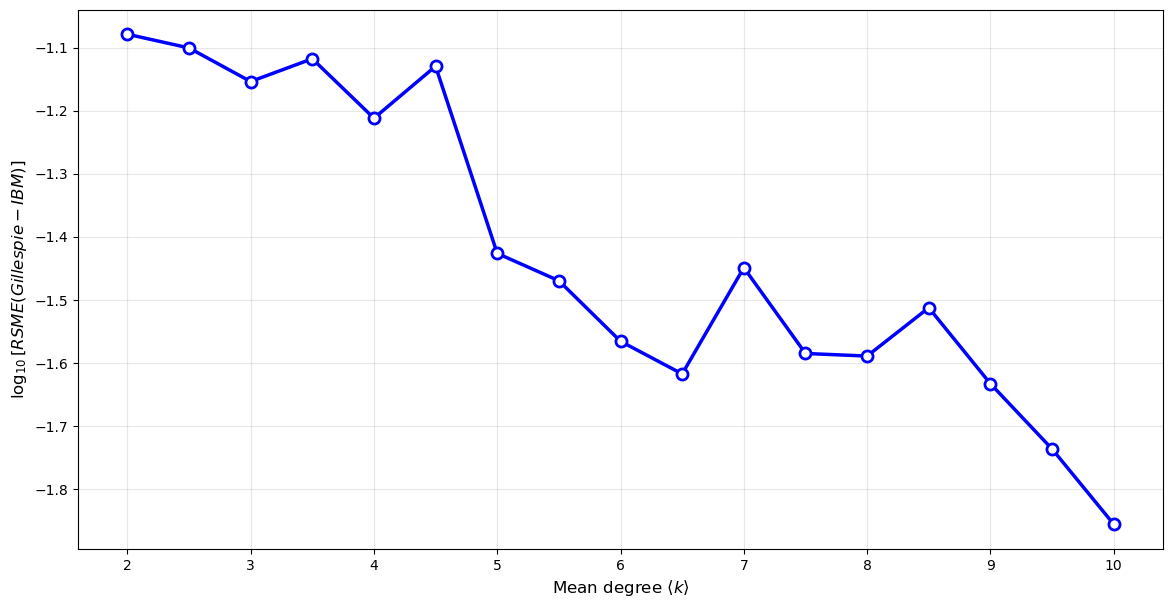

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import networkx as nx

np.random.seed(42)

# ============================================================
#  PARAMETERS
# ============================================================
beta    = 0.3
gamma   = 0.1
D_I     = 0.01
M       = 3
N       = 1000
T_max   = 100.0
I0_frac = 0.1

A_meta   = D_I * np.array([[0,1,0],[1,0,1],[0,1,0]], dtype=float)
D_meta   = np.diag(A_meta.sum(axis=1))
L_meta   = D_meta - A_meta
k_avg_values = [2,2.5,3,3.5,4,4.5,5,5.5,6,6.5,7,7.5,8,8.5,9,9.5,10]

##Build the ER networks
def build_ER_network(N, k_avg, seed=0):
    G   = nx.erdos_renyi_graph(N, k_avg/(N-1), seed=seed)
    A   = nx.to_numpy_array(G)
    adj = [list(G.neighbors(i)) for i in range(N)]
    return adj, A
# Gillespie
def gillespie_SIR(beta, gamma, A_meta, M, N, adjs, T_max, seed=3):
    state = [np.zeros(N, dtype=int) for _ in range(M)] 
    state[0][:max(1, int(0.10 * N))] = 1
    times = [0.0]
    I_counts = [[np.sum(s == 1) for s in state]]
    t = 0.0
    for _ in range(800_000):
        rates = []; events = []
        for mu in range(M):
            adj = adjs[mu]; s = state[mu]
            for i in range(N):
                if s[i] == 0:
                    inf_nb = sum(1 for j in adj[i] if s[j] == 1)
                    if inf_nb > 0:
                        rates.append(beta * inf_nb)
                        events.append(('infect', mu, i, None))
                elif s[i] == 1:
                    rates.append(gamma)
                    events.append(('recover', mu, i, None))
                    for nu in range(M):
                        if A_meta[mu, nu] > 0:
                            rates.append(A_meta[mu, nu])
                            events.append(('migrate', mu, i, nu))
        total_rate = sum(rates)
        if total_rate == 0:
            break
        t += np.random.exponential(1.0 / total_rate)
        if t > T_max: 
            break
        r = np.random.random() * total_rate
        cumsum = 0
        for idx, rate in enumerate(rates):
            cumsum += rate
            if r <= cumsum:
                etype, mu, i, nu = events[idx]
                break
        if etype == 'infect': state[mu][i] = 1
        elif etype == 'recover': state[mu][i] = 2
        elif etype == 'migrate':
            dest_S = np.where(state[nu] == 0)[0]
            if len(dest_S) > 0:
                state[mu][i] = 0
                state[nu][dest_S[np.random.randint(len(dest_S))]] = 1
        times.append(t)
        I_counts.append([np.sum(s == 1) for s in state])
    I_counts = np.array(I_counts, dtype=float) / N
    return np.array(times), I_counts.mean(axis=1)

#IBM ODE
def ode_IBM_SIR(t, X, beta, gamma, N, M, As, L_meta):
    X = np.clip(X, 0.0, 1.0)
    dX = np.zeros(3 * N * M)
    for mu in range(M):
        S_mu = X[mu*3*N : mu*3*N + N]
        I_mu = X[mu*3*N + N : mu*3*N + 2*N]
        infection = beta * S_mu * (As[mu] @ I_mu)
        recovery = gamma * I_mu
        mig_S = sum(L_meta[mu,nu]*X[nu*3*N : nu*3*N + N] for nu in range(M))
        mig_I = sum(L_meta[mu,nu]*X[nu*3*N + N : nu*3*N + 2*N] for nu in range(M))
        dX[mu*3*N : mu*3*N + N] = - infection - mig_S
        dX[mu*3*N + N : mu*3*N + 2*N] = +infection - recovery - mig_I
        dX[mu*3*N + 2*N: mu*3*N + 3*N] = +recovery
    return dX

def run_IBM(beta, gamma, N, M, As, L_meta, T_max):
    X0 = np.zeros(3 * N * M)
    for mu in range(M): X0[mu*3*N : mu*3*N + N] = 1.0
    X0[0:N] = 1.0 - I0_frac; X0[N:2*N] = I0_frac
    sol = solve_ivp(ode_IBM_SIR, [0, T_max], X0, t_eval=np.linspace(0, T_max, 500),
                    args=(beta, gamma, N, M, As, L_meta),method='RK45',  max_step=0.5)
    return sol.t, np.array([sol.y[mu*3*N+N : mu*3*N+2*N].mean(axis=0) for mu in range(M)]).mean(axis=0)

#Loop
k_vals = []; rmse_vals = []
for k_avg in k_avg_values:
    adjs, As = [], []
    for mu in range(M):
        adj, A = build_ER_network(N, k_avg, seed=mu+42)
        adjs.append(adj); As.append(A)
    t_gil, I_gil = gillespie_SIR(beta, gamma, A_meta, M, N, adjs, T_max)
    t_ibm, I_ibm = run_IBM(beta, gamma, N, M, As, L_meta, T_max)
    t_common = np.linspace(0, T_max, 300)
    rmse = np.sqrt(np.mean((np.interp(t_common, t_gil, I_gil) - np.interp(t_common, t_ibm, I_ibm))**2))
    k_vals.append(k_avg); rmse_vals.append(rmse) 

#Figure
plt.figure(figsize=(14, 7))
plt.plot(k_vals, np.log10(rmse_vals), 'bo-', lw=2.5, markersize=8,
markerfacecolor='white', markeredgewidth=2)
plt.xlabel(r'Mean degree $\langle k \rangle$', fontsize=12)
plt.ylabel(r'$\log_{10}[RSME(Gillespie - IBM)]$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('error_vs_k_ER.png')
plt.show()

  Gillespie...
  IBM ODE...
  HMF ODE...
  Gillespie...
  IBM ODE...
  HMF ODE...


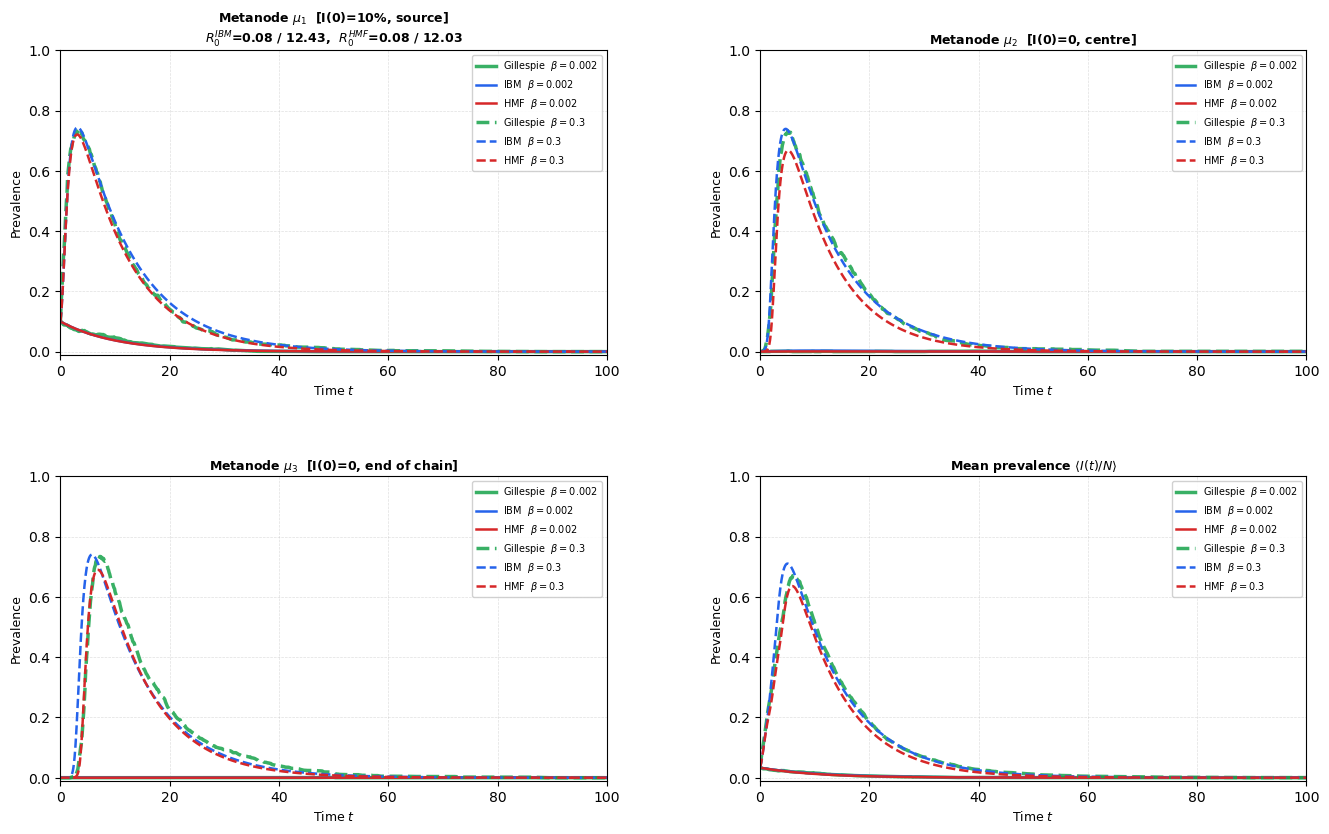

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
import networkx as nx

np.random.seed(3)

# ============================================================
#  PARAMETERS
# ============================================================
gamma    = 0.1
D_I      = 0.01
M        = 3
N        = 1000
T_max    = 100
m_BA     = 3
beta_list = [0.002, 0.3]

A_meta   = D_I * np.array([[0,1,0],[1,0,1],[0,1,0]], dtype=float)
D_meta   = np.diag(A_meta.sum(axis=1))
L_meta   = D_meta - A_meta
D_mu_vec = np.diag(L_meta)
D_mu0    = D_mu_vec[0] # DI.k_mu1
pi_mu0   = 1.0 / M # the stationary distribution

# Gillespie
def gillespie_SIR(beta, gamma, A_meta, M, N, adjs, T_max, seed=3):
    #np.random.seed(seed)
    state = [np.zeros(N, dtype=int) for _ in range(M)] 
    state[0][:max(1, int(0.10 * N))] = 1
    times = [0.0]
    I_counts = [[np.sum(s == 1) for s in state]]
    t = 0.0
    for _ in range(800_000):
        rates = []; events = []
        for mu in range(M):
            adj = adjs[mu]; s = state[mu]
            for i in range(N):
                if s[i] == 0:
                    inf_nb = sum(1 for j in adj[i] if s[j] == 1)
                    if inf_nb > 0:
                        rates.append(beta * inf_nb)
                        events.append(('infect', mu, i, None))
                elif s[i] == 1:
                    rates.append(gamma)
                    events.append(('recover', mu, i, None))
                    for nu in range(M):
                        if A_meta[mu, nu] > 0:
                            rates.append(A_meta[mu, nu])
                            events.append(('migrate', mu, i, nu))
        total_rate = sum(rates)
        if total_rate == 0:
            break
        t += np.random.exponential(1.0 / total_rate)
        if t > T_max: 
            break
        r = np.random.random() * total_rate
        cumsum = 0
        for idx, rate in enumerate(rates):
            cumsum += rate
            if r <= cumsum:
                etype, mu, i, nu = events[idx]
                break
        if etype == 'infect': state[mu][i] = 1
        elif etype == 'recover': state[mu][i] = 2
        elif etype == 'migrate':
            dest_S = np.where(state[nu] == 0)[0]
            if len(dest_S) > 0:
                state[mu][i] = 0
                state[nu][dest_S[np.random.randint(len(dest_S))]] = 1
        times.append(t)
        I_counts.append([np.sum(s == 1) for s in state])
    return np.array(times), np.array(I_counts, dtype=float) / N

#IBM ODE
def ode_IBM_SIR(t, X, beta, gamma, N, M, As, L_meta):
    X = np.clip(X, 0.0, 1.0)
    dX = np.zeros(3 * N * M)
    for mu in range(M):
        S_mu = X[mu*3*N : mu*3*N + N]
        I_mu = X[mu*3*N + N : mu*3*N + 2*N]
        infection = beta * S_mu * (As[mu] @ I_mu)
        recovery = gamma * I_mu
        mig_S = sum(L_meta[mu,nu]*X[nu*3*N : nu*3*N + N] for nu in range(M))
        mig_I = sum(L_meta[mu,nu]*X[nu*3*N + N : nu*3*N + 2*N] for nu in range(M))
        dX[mu*3*N : mu*3*N + N] = - infection - mig_S
        dX[mu*3*N + N : mu*3*N + 2*N] = +infection - recovery - mig_I
        dX[mu*3*N + 2*N: mu*3*N + 3*N] = +recovery
    return dX

# HMF ODE
def build_patch_info(p_ks, degrees_all, M):
    patch_info = []; offset = 0
    for mu in range(M):
        k_classes = np.array(sorted(p_ks[mu].keys()), dtype=float)
        p_k_arr = np.array([p_ks[mu][int(k)] for k in k_classes])
        n_k = len(k_classes)
        patch_info.append({'k_classes': k_classes, 'p_k_arr': p_k_arr,
                           'k_mean': float(np.mean(degrees_all[mu])),
                           'n_k': n_k, 'offset': offset})
        offset += n_k
    return patch_info, offset

def ode_HMF_SIR(t, X, beta, gamma, M, D_mu_vec, A_meta, patch_info, total_k):
    X = np.clip(X, 0.0, 1.0)
    dX = np.zeros_like(X)
    Theta = np.zeros(M); sumI = np.zeros(M); sumS = np.zeros(M)
    for mu in range(M):
        info = patch_info[mu]; off = info['offset']; n_k = info['n_k']
        I_kmu = X[total_k + off : total_k + off + n_k]
        S_kmu = X[off : off + n_k]
        Theta[mu] = np.dot(info['k_classes']*info['p_k_arr'], I_kmu) / info['k_mean']
        sumI[mu] = np.dot(info['p_k_arr'], I_kmu)
        sumS[mu] = np.dot(info['p_k_arr'], S_kmu)
    for mu in range(M):
        info = patch_info[mu]; off = info['offset']; n_k = info['n_k']
        S_kmu = X[off : off + n_k]
        I_kmu = X[total_k + off : total_k + off + n_k]
        k_cls = info['k_classes']; p_k_arr = info['p_k_arr']
        infection = beta * k_cls * S_kmu * Theta[mu]
        recovery = gamma * I_kmu
        outflow_S = D_mu_vec[mu] * S_kmu
        outflow_I = D_mu_vec[mu] * I_kmu
        inflow_S = p_k_arr * sum(A_meta[nu,mu]*sumS[nu] for nu in range(M) if A_meta[nu,mu]>0)
        inflow_I = p_k_arr * sum(A_meta[nu,mu]*sumI[nu] for nu in range(M) if A_meta[nu,mu]>0)
        dX[off : off + n_k] = -infection - outflow_S + inflow_S
        dX[total_k + off : total_k + off + n_k] = infection - recovery  - outflow_I + inflow_I
        dX[2*total_k+off : 2*total_k+off + n_k] = recovery
    return dX

#Build the networks
adjs, As, degrees_all, p_ks = [], [], [], []
for mu in range(M):
    G = nx.barabasi_albert_graph(N, m_BA, seed=mu+1)
    A = nx.to_numpy_array(G)
    adj = [list(G.neighbors(i)) for i in range(N)]
    deg = np.array([d for _, d in G.degree()])
    uk, cnt = np.unique(deg, return_counts=True)
    pk = {int(k): c / (N-1) for k, c in zip(uk, cnt)}
    adjs.append(adj); As.append(A)
    degrees_all.append(deg); p_ks.append(pk)

#Loop
t_eval = np.linspace(0, T_max, 2000)
t_fine = np.linspace(0, T_max, 1000)
results = []

for beta in beta_list:
    patch_info, total_HMF = build_patch_info(p_ks, degrees_all, M)

    X0_IBM = np.zeros(3 * N * M)
    for mu in range(M): X0_IBM[mu*3*N : mu*3*N + N] = 1.0
    X0_IBM[0:N] = 0.90; X0_IBM[N:2*N] = 0.10

    X0_HMF = np.zeros(3 * total_HMF)
    info0  = patch_info[0]; off0 = info0['offset']; n_k0 = info0['n_k']
    X0_HMF[off0 : off0 + n_k0]                         = 0.90
    X0_HMF[total_HMF + off0 : total_HMF + off0 + n_k0] = 0.10
    for mu in range(1, M):
        info = patch_info[mu]
        X0_HMF[info['offset'] : info['offset'] + info['n_k']] = 1.0

    print("  Gillespie...")
    t_gil, I_gil = gillespie_SIR(beta, gamma, A_meta, M, N, adjs, T_max)

    print("  IBM ODE...")
    sol_IBM = solve_ivp(ode_IBM_SIR, [0, T_max], X0_IBM, t_eval=t_eval,
                        args=(beta, gamma, N, M, As, L_meta),
                        method='RK45', max_step=0.5)
    I_IBM = np.array([sol_IBM.y[mu*3*N + N : mu*3*N + 2*N].mean(axis=0)
                      for mu in range(M)])

    print("  HMF ODE...")
    sol_HMF = solve_ivp(ode_HMF_SIR, [0, T_max], X0_HMF, t_eval=t_eval,
                        args=(beta, gamma, M, D_mu_vec, A_meta, patch_info, total_HMF),
                        method='RK45', max_step=0.5)
    I_HMF = np.zeros((M, len(sol_HMF.t)))
    for mu in range(M):
        info = patch_info[mu]; off = info['offset']; n_k = info['n_k']
        I_HMF[mu] = (info['p_k_arr'][:,None] *
                     sol_HMF.y[total_HMF + off : total_HMF + off + n_k]).sum(axis=0)
        
    results.append({'beta': beta, 't_gil': t_gil, 'I_gil': I_gil,'I_IBM': I_IBM, 't_IBM': sol_IBM.t,
                    'I_HMF': I_HMF, 't_HMF': sol_HMF.t})

#Figure
colors_model = {'gil': '#16a34a', 'ibm': '#2563eb', 'hmf': '#d62728'}
ls_beta      = {0.002: '-', 0.3: '--'}


# Computation of the thresholds for mu1

rho_A   = float(np.max(np.abs(np.linalg.eigvalsh(As[0]))))
k2_over_k = float(np.mean(degrees_all[0]**2) / np.mean(degrees_all[0]))

R0_IBM_low  = (beta_list[0] * pi_mu0 * rho_A)   / (gamma + D_mu0)
R0_IBM_high = (beta_list[1] * pi_mu0 * rho_A)   / (gamma + D_mu0)
R0_HMF_low  = (beta_list[0] * pi_mu0 * k2_over_k) / (gamma + D_mu0)
R0_HMF_high = (beta_list[1] * pi_mu0 * k2_over_k) / (gamma + D_mu0)

#Figures
patch_titles = [
    f'Metanode $\\mu_1$  [I(0)=10%, source]\n'
    f'$R_0^{{IBM}}$={R0_IBM_low:.2f} / {R0_IBM_high:.2f},  '
    f'$R_0^{{HMF}}$={R0_HMF_low:.2f} / {R0_HMF_high:.2f}',
    r'Metanode $\mu_2$  [I(0)=0, centre]',
    r'Metanode $\mu_3$  [I(0)=0, end of chain]',
    r'Mean prevalence $\langle I(t)/N\rangle$'
]
fig = plt.figure(figsize=(14, 8.8), facecolor='white')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.28,left=0.08, right=0.97, top=0.91, bottom=0.08)
axes = [fig.add_subplot(gs[r, c]) for r, c in [(0,0),(0,1),(1,0),(1,1)]]

for ax, title in zip(axes, patch_titles):
    ax.set_title(title, fontsize=9, fontweight='bold', pad=5)
    ax.set_xlabel('Time $t$', fontsize=9)
    ax.set_ylabel('Prevalence', fontsize=9)
    ax.set_xlim(0, T_max); ax.set_ylim(-0.01, 1.0)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

for res in results:
    beta = res['beta']
    ls = ls_beta[beta]
    for ax_idx, ax in enumerate(axes):
        if ax_idx < M:
            mu = ax_idx
            g_curve = np.interp(t_fine, res['t_gil'], res['I_gil'][:, mu])
            ibm_curve = res['I_IBM'][mu]
            hmf_curve = res['I_HMF'][mu]
        else:
            g_curve   = np.interp(t_fine, res['t_gil'], res['I_gil'].mean(axis=1))
            ibm_curve = res['I_IBM'].mean(axis=0)
            hmf_curve = res['I_HMF'].mean(axis=0)
        ax.plot(t_fine, g_curve,color=colors_model['gil'],lw=2.5, ls=ls, alpha=0.85,label=f'Gillespie  $\\beta={beta}$')
        ax.plot(res['t_IBM'], ibm_curve, color=colors_model['ibm'], lw=1.8, ls=ls,label=f'IBM  $\\beta={beta}$')
        ax.plot(res['t_HMF'], hmf_curve, color=colors_model['hmf'], lw=1.8, ls=ls,label=f'HMF  $\\beta={beta}$')

for ax in axes:
    ax.legend(fontsize=7, loc='upper right',facecolor='white', edgecolor='#cccccc', framealpha=0.9)

plt.savefig('BA_vary_beta.png')
plt.show()

Building ER networks...
beta_c IBM = 0.0463
beta=0.0050 ... Gil=0.003  IBM=0.005
beta=0.0089 ... Gil=0.005  IBM=0.008
beta=0.0129 ... Gil=0.010  IBM=0.018
beta=0.0168 ... Gil=0.034  IBM=0.064
beta=0.0208 ... Gil=0.036  IBM=0.227
beta=0.0247 ... Gil=0.048  IBM=0.468
beta=0.0287 ... Gil=0.215  IBM=0.636
beta=0.0326 ... Gil=0.531  IBM=0.732
beta=0.0366 ... Gil=0.614  IBM=0.792
beta=0.0405 ... Gil=0.686  IBM=0.833
beta=0.0445 ... Gil=0.786  IBM=0.863
beta=0.0484 ... Gil=0.789  IBM=0.886
beta=0.0524 ... Gil=0.819  IBM=0.904
beta=0.0563 ... Gil=0.843  IBM=0.918
beta=0.0603 ... Gil=0.871  IBM=0.930
beta=0.0642 ... Gil=0.886  IBM=0.939
beta=0.0682 ... Gil=0.905  IBM=0.947
beta=0.0721 ... Gil=0.909  IBM=0.954
beta=0.0761 ... Gil=0.917  IBM=0.959
beta=0.0800 ... Gil=0.938  IBM=0.964
beta_c Gillespie ≈ 0.024736842105263158


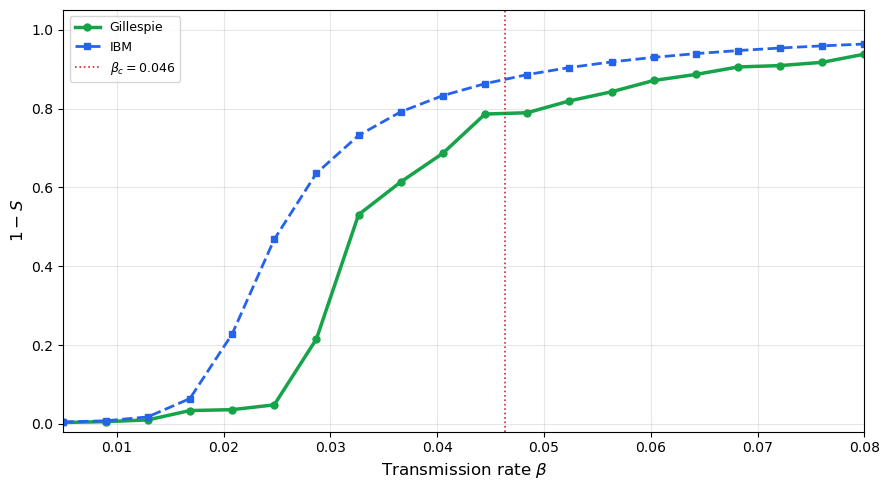

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import networkx as nx

np.random.seed(42)

# ============================================================
#  PARAMETERS
# ============================================================
gamma   = 0.1
D_I     = 0.01
M       = 3
N       = 2000
T_max   = 100.0
I0_frac = 0.01
N_RUNS  = 1
k_avg   = 6

beta_values = np.linspace(0.005, 0.08, 20)

A_meta   = D_I * np.array([[0,1,0],[1,0,1],[0,1,0]], dtype=float)
D_meta   = np.diag(A_meta.sum(axis=1))
L_meta   = D_meta - A_meta
D_mu_vec = np.diag(L_meta)
pi_mu0   = 1.0 / M
D_mu0    = D_mu_vec[0]

# ============================================================
#  BUILD ER NETWORK
# ============================================================
print("Building ER networks...")
adjs, As, degrees_all = [], [], []
for mu in range(M):
    G   = nx.erdos_renyi_graph(N, k_avg/(N-1), seed=mu+42)
    A   = nx.to_numpy_array(G)
    adj = [list(G.neighbors(i)) for i in range(N)]
    deg = np.array([d for _, d in G.degree()])
    adjs.append(adj); As.append(A); degrees_all.append(deg)

rho_A    = float(np.max(np.abs(np.linalg.eigvalsh(As[0]))))
beta_c_IBM = (gamma + D_mu0) / (pi_mu0 * rho_A)
print(f"beta_c IBM = {beta_c_IBM:.4f}")

# ============================================================
#  GILLESPIE SIR
# ============================================================
def gillespie_final_size(beta, gamma, A_meta, M, N, adjs, T_max, seed=42):
    np.random.seed(seed)
    state = [np.zeros(N, dtype=int) for _ in range(M)]
    state[0][:max(1, int(I0_frac * N))] = 1
    t = 0.0
    for _ in range(300_000):
        rates = []; events = []
        for mu in range(M):
            adj = adjs[mu]; s = state[mu]
            for i in range(N):
                if s[i] == 0:
                    inf_nb = sum(1 for j in adj[i] if s[j] == 1)
                    if inf_nb > 0:
                        rates.append(beta * inf_nb)
                        events.append(('infect', mu, i, None))
                elif s[i] == 1:
                    rates.append(gamma)
                    events.append(('recover', mu, i, None))
                    for nu in range(M):
                        if A_meta[mu, nu] > 0:
                            rates.append(A_meta[mu, nu])
                            events.append(('migrate', mu, i, nu))
        total_rate= sum(rates)
        if total_rate == 0: break
        t += np.random.exponential(1.0 / total_rate)
        if t > T_max: break
        r = np.random.random() * total_rate
        cumsum = 0
        for idx, rate in enumerate(rates):
            cumsum += rate
            if r <= cumsum:
                etype, mu, i, nu = events[idx]; break
        if etype == 'infect':    state[mu][i] = 1
        elif etype == 'recover': state[mu][i] = 2
        elif etype == 'migrate':
            dest_S = np.where(state[nu] == 0)[0]
            if len(dest_S) > 0:
                state[mu][i] = 0
                state[nu][dest_S[np.random.randint(len(dest_S))]] = 1
    total_S = sum(np.sum(s == 0) for s in state)
    return 1.0 - total_S / (N * M)

# ============================================================
#  IBM ODE
# ============================================================
def ode_IBM_SIR(t, X, beta, gamma, N, M, As, L_meta):
    X = np.clip(X, 0.0, 1.0)
    dX = np.zeros(3 * N * M)
    for mu in range(M):
        S_mu = X[mu*3*N : mu*3*N + N]
        I_mu = X[mu*3*N + N : mu*3*N + 2*N]
        infection = beta * S_mu * (As[mu] @ I_mu)
        recovery  = gamma * I_mu
        mig_S = sum(L_meta[mu,nu]*X[nu*3*N     : nu*3*N +   N] for nu in range(M))
        mig_I = sum(L_meta[mu,nu]*X[nu*3*N + N : nu*3*N + 2*N] for nu in range(M))
        dX[mu*3*N      : mu*3*N +   N] = -infection - mig_S
        dX[mu*3*N + N  : mu*3*N + 2*N] =  infection - recovery - mig_I
        dX[mu*3*N + 2*N: mu*3*N + 3*N] =  recovery
    return dX

def IBM_final_size(beta, gamma, N, M, As, L_meta, T_max):
    X0 = np.zeros(3 * N * M)
    for mu in range(M): X0[mu*3*N : mu*3*N + N] = 1.0
    X0[0:N] = 1.0 - I0_frac; X0[N:2*N] = I0_frac
    sol = solve_ivp(ode_IBM_SIR, [0, T_max], X0, t_eval=[T_max],
                    args=(beta, gamma, N, M, As, L_meta),
                    method='RK45', rtol=1e-5, atol=1e-7, max_step=0.5)
    total_S = sum(sol.y[mu*3*N : mu*3*N + N, -1].sum() for mu in range(M))
    return 1.0 - total_S / (N * M)

# ============================================================
#  MAIN LOOP
# ============================================================
fs_gil_mean = []
fs_gil_std  = []
fs_ibm      = []

for beta in beta_values:
    print(f"beta={beta:.4f} ...", end=' ', flush=True)
    runs = [gillespie_final_size(beta, gamma, A_meta, M, N, adjs, T_max, seed=s)
            for s in range(N_RUNS)]
    fs_gil_mean.append(np.mean(runs))
    fs_gil_std.append(np.std(runs))
    fs_ibm.append(IBM_final_size(beta, gamma, N, M, As, L_meta, T_max))
    print(f"Gil={fs_gil_mean[-1]:.3f}  IBM={fs_ibm[-1]:.3f}")

fs_gil_mean = np.array(fs_gil_mean)
fs_gil_std  = np.array(fs_gil_std)
fs_ibm      = np.array(fs_ibm)
threshold  = 0.05
beta_c_Gil = None
for i in range(len(beta_values)-1):
    if fs_gil_mean[i] < threshold and fs_gil_mean[i+1] >= threshold:
        beta_c_Gil = beta_values[i]
        break
print(f"beta_c Gillespie ≈ {beta_c_Gil}")

# ============================================================
#  FIGURE
# ============================================================
if beta_c_Gil is not None:
    ax.axvline(beta_c_Gil, color='#16a34a', lw=1.2, ls=':',
               label=f'$\\beta_c$ Gillespie $\\approx {beta_c_Gil:.3f}$')
fig, ax = plt.subplots(figsize=(9, 5))

ax.fill_between(beta_values,
                fs_gil_mean - fs_gil_std,
                fs_gil_mean + fs_gil_std,
                color='#16a34a', alpha=0.15)
ax.plot(beta_values, fs_gil_mean, color='#16a34a', lw=2.5, marker='o',
        markersize=5, label=f'Gillespie')
ax.plot(beta_values, fs_ibm, color='#2563eb', lw=2.0, ls='--', marker='s',
        markersize=5, label='IBM')
ax.axvline(beta_c_IBM, color='#d62728', lw=1.2, ls=':',
           label=f'$\\beta_c= {beta_c_IBM:.3f}$')

ax.set_xlabel(r'Transmission rate $\beta$', fontsize=12)
ax.set_ylabel(r'$1 - S$', fontsize=12)
ax.legend(fontsize=9, facecolor='white', edgecolor='#cccccc')
ax.grid(True, alpha=0.3)
ax.set_xlim(beta_values[0], beta_values[-1])
ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.savefig('final_size_vs_beta_v2.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()